# Model running test
モデルが動くことを確認したいと思っています  
できました
260213 本澤

In [1]:
import torch
import torch.nn as nn
import torchvision

import sys

sys.path.append("/workspace/moritak/toxpath-ssl-rep/src")

from sslmodel import sslutils

In [2]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda:0


In [3]:
encoder = torchvision.models.resnet18(weights=None)
size = 512
backbone = nn.Sequential(
    *list(encoder.children())[:-1],
)

In [4]:
model, _ = sslutils.BarlowTwins(DEVICE=DEVICE).prepare_model(
    backbone,
    head_size=512,
)

In [5]:
MODEL_PATH="/workspace/share/models/ssl/liver_fold_model/bt_fold0/model_ssl.pt"

In [6]:
model.load_state_dict(
    torch.load(MODEL_PATH)
)

<All keys matched successfully>

In [7]:
import numpy as np
test_images = np.load("/workspace/hdd/hdd_days/TGGATEs/WSI/Liver/patch/4 day/2589.svs.npy", mmap_mode='r')

In [8]:
print(test_images.shape)

(2000, 256, 256, 3)


In [9]:
results_list = []
batch_size = 32

for i in range(0, len(test_images), batch_size):
    batch_np = test_images[i : i + batch_size]
    
    test_tensor = torch.from_numpy(batch_np).to(DEVICE).float()
    
    with torch.no_grad():
        result = model(test_tensor.permute(0, 3, 1, 2))

    results_list.append(result.cpu())

full_result = torch.cat(results_list, dim=0)

/tmp/ipykernel_3903577/64084125.py:7: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  test_tensor = torch.from_numpy(batch_np).to(DEVICE).float()


In [10]:
print(full_result.shape)

torch.Size([2000, 128])


/tmp/ipykernel_3903577/1674032208.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(


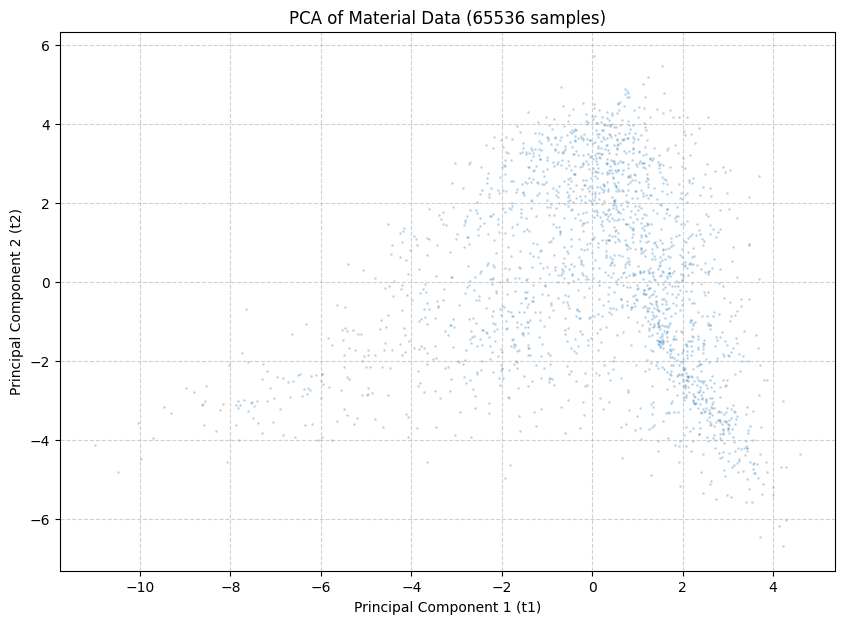

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()
scaled_result = scale.fit_transform(full_result)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_result)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    pca_result[:, 0], 
    pca_result[:, 1], 
    cmap='jet', 
    s=1,             
    alpha=0.2        
)

plt.xlabel('Principal Component 1 (t1)')
plt.ylabel('Principal Component 2 (t2)')
plt.title('PCA of Material Data (65536 samples)')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
